In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel('BASE_2_Clientes_Manga.xlsx')
df.head(10)

,tipo_cliente,importancia_manga_produto_final_1a10,importancia_preco,importancia_certificacoes,aceita_refugo_como_mp,volume_tipico_compra_ton_mes,frequencia_compra_mensal
0,B2B,5,Média,Baixa,Sim,299,3
1,B2B,10,Alta,Baixa,Sim,1326,4
2,B2B,7,NaN,Média,Sim,1661,4
3,B2B,8,Alta,Média,Sim,1195,3
4,B2B,9,Média,Média,Sim,1783,4
5,B2B,7,Média,Baixa,Não,334,5
6,B2B,9,Alta,Baixa,Sim,961,3
7,B2C,9,Média,Média,Não,549,3
8,B2B,6,Baixa,Alta,Não,322,4
9,B2B,8,Alta,Baixa,Não,876,3


count    7000.000000
mean        7.544714
std         1.609108
min         4.000000
25%         6.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: importancia_manga_produto_final_1a10, dtype: float64

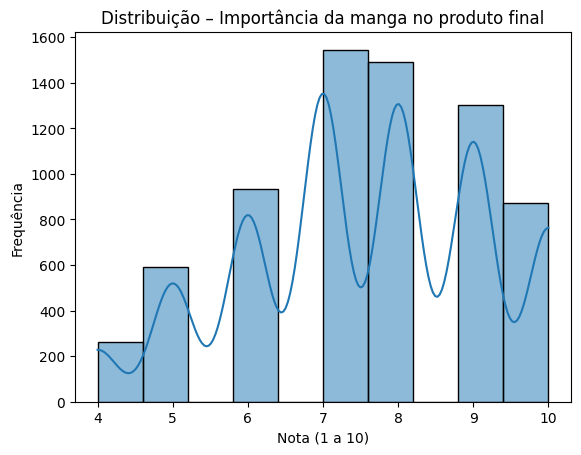

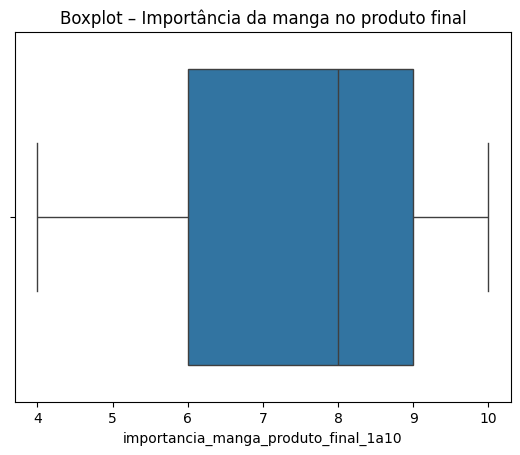

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

col = 'importancia_manga_produto_final_1a10'

display(df[col].describe())

plt.figure()
sns.histplot(df[col], bins=10, kde=True)
plt.title('Distribuição – Importância da manga no produto final')
plt.xlabel('Nota (1 a 10)')
plt.ylabel('Frequência')
plt.show()

plt.figure()
sns.boxplot(x=df[col])
plt.title('Boxplot – Importância da manga no produto final')
plt.show()


count    7000.000000
mean      969.017143
std       653.404398
min        80.000000
25%       356.000000
50%       935.500000
75%      1474.250000
max      2600.000000
Name: volume_tipico_compra_ton_mes, dtype: float64

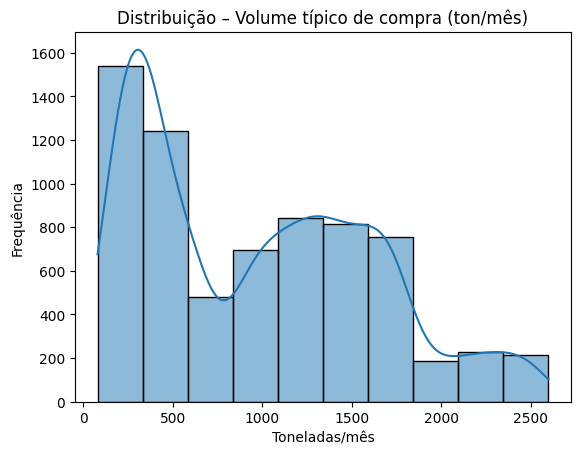

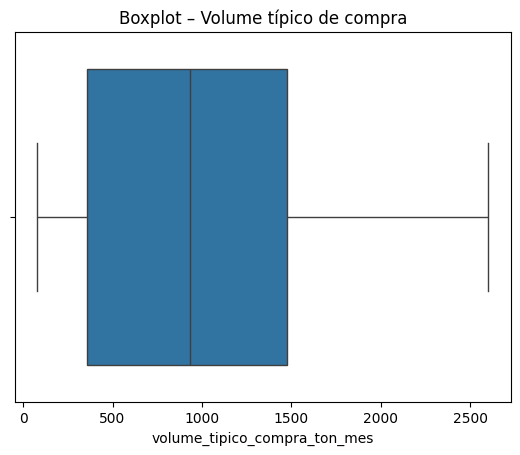

In [4]:
col = 'volume_tipico_compra_ton_mes'

display(df[col].describe())

plt.figure()
sns.histplot(df[col], bins=10, kde=True)
plt.title('Distribuição – Volume típico de compra (ton/mês)')
plt.xlabel('Toneladas/mês')
plt.ylabel('Frequência')
plt.show()

plt.figure()
sns.boxplot(x=df[col])
plt.title('Boxplot – Volume típico de compra')
plt.show()


count    7000.000000
mean        3.349286
std         0.851530
min         2.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: frequencia_compra_mensal, dtype: float64

frequencia_compra_mensal
3    42.514286
4    32.600000
2    15.814286
5     9.071429
Name: proportion, dtype: float64

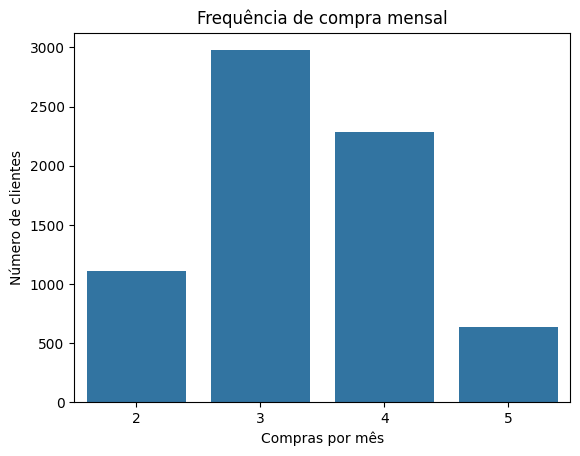

In [13]:
col = 'frequencia_compra_mensal'

display(df[col].describe())
display(df[col].value_counts(dropna=False, normalize=True)*100)

plt.figure()
sns.countplot(x=df[col])
plt.title('Frequência de compra mensal')
plt.xlabel('Compras por mês')
plt.ylabel('Número de clientes')
plt.show()

importancia_preco
Alta     2969
Média    2199
Baixa    1202
NaN       630
Name: count, dtype: int64

importancia_preco
Alta     42.414286
Média    31.414286
Baixa    17.171429
NaN       9.000000
Name: proportion, dtype: float64

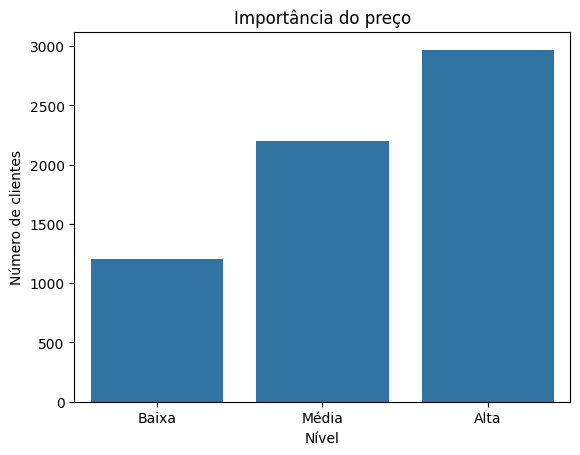

In [10]:
col = 'importancia_preco'

display(df[col].value_counts(dropna=False))
display(df[col].value_counts(dropna=False, normalize=True)*100)

plt.figure()
sns.countplot(x=df[col], order=['Baixa', 'Média', 'Alta'])
plt.title('Importância do preço')
plt.xlabel('Nível')
plt.ylabel('Número de clientes')
plt.show()


importancia_certificacoes
Média    3079
Alta     2043
Baixa    1878
Name: count, dtype: int64

importancia_certificacoes
Média    43.985714
Alta     29.185714
Baixa    26.828571
Name: proportion, dtype: float64

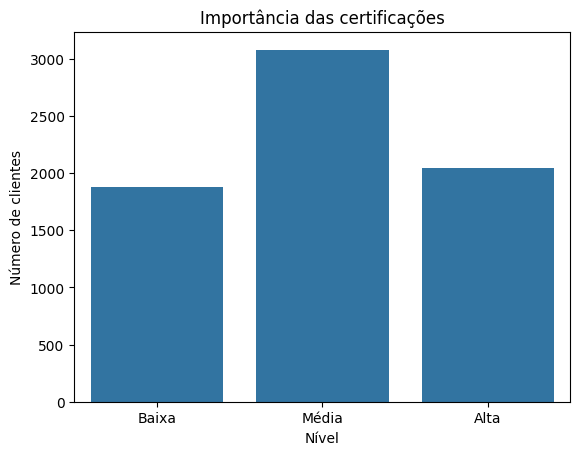

In [12]:
col = 'importancia_certificacoes'

display(df[col].value_counts(dropna=False))
display(df[col].value_counts(dropna=False, normalize=True)*100)

plt.figure()
sns.countplot(x=df[col], order=['Baixa', 'Média', 'Alta'])
plt.title('Importância das certificações')
plt.xlabel('Nível')
plt.ylabel('Número de clientes')
plt.show()


tipo_cliente
B2B    89.085714
B2C    10.914286
Name: proportion, dtype: float64

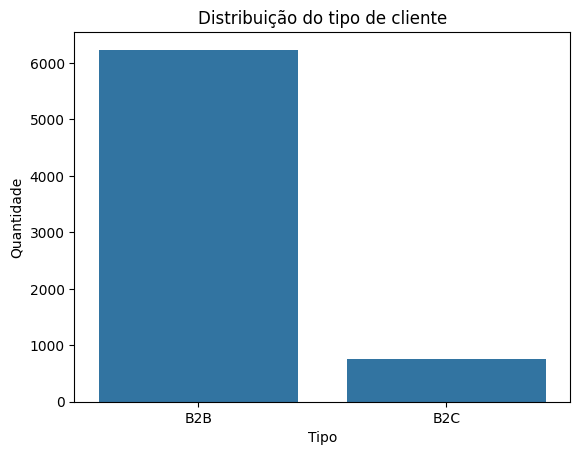

In [8]:
col = 'tipo_cliente'

display(df[col].value_counts(normalize=True) * 100)

plt.figure()
sns.countplot(x=df[col])
plt.title('Distribuição do tipo de cliente')
plt.xlabel('Tipo')
plt.ylabel('Quantidade')
plt.show()


aceita_refugo_como_mp
Sim    63.1
Não    36.9
Name: proportion, dtype: float64

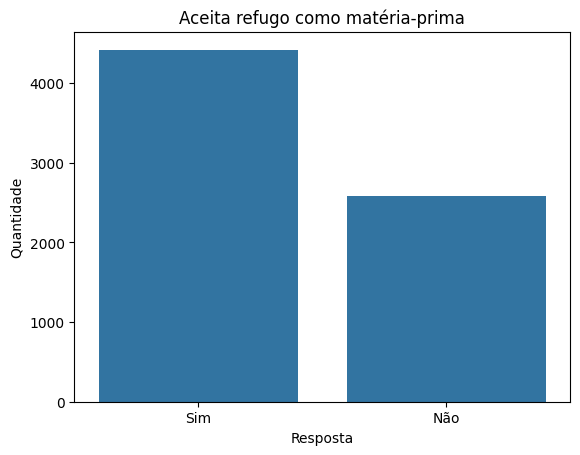

In [14]:
col = 'aceita_refugo_como_mp'

display(df[col].value_counts(normalize=True) * 100)

plt.figure()
sns.countplot(x=df[col])
plt.title('Aceita refugo como matéria-prima')
plt.xlabel('Resposta')
plt.ylabel('Quantidade')
plt.show()


In [16]:
target_col = "importancia_preco"

group_cols = [
    "tipo_cliente",
    "importancia_certificacoes",
    "aceita_refugo_como_mp"
]

df[target_col] = (
    df
    .groupby(group_cols)[target_col]
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)